In [1]:
#Carregar as bibliotecas

import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt
import os
import cv2
from tqdm import tqdm
import random
from sklearn.model_selection import train_test_split
import tensorflow as tf
from tensorflow import keras
from tensorflow.math import confusion_matrix
import seaborn as sns
from tensorflow.keras import layers, models, callbacks
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import matplotlib.pyplot as plt
import numpy as np
tf.random.set_seed(3)

2026-04-11 01:06:15.681645: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


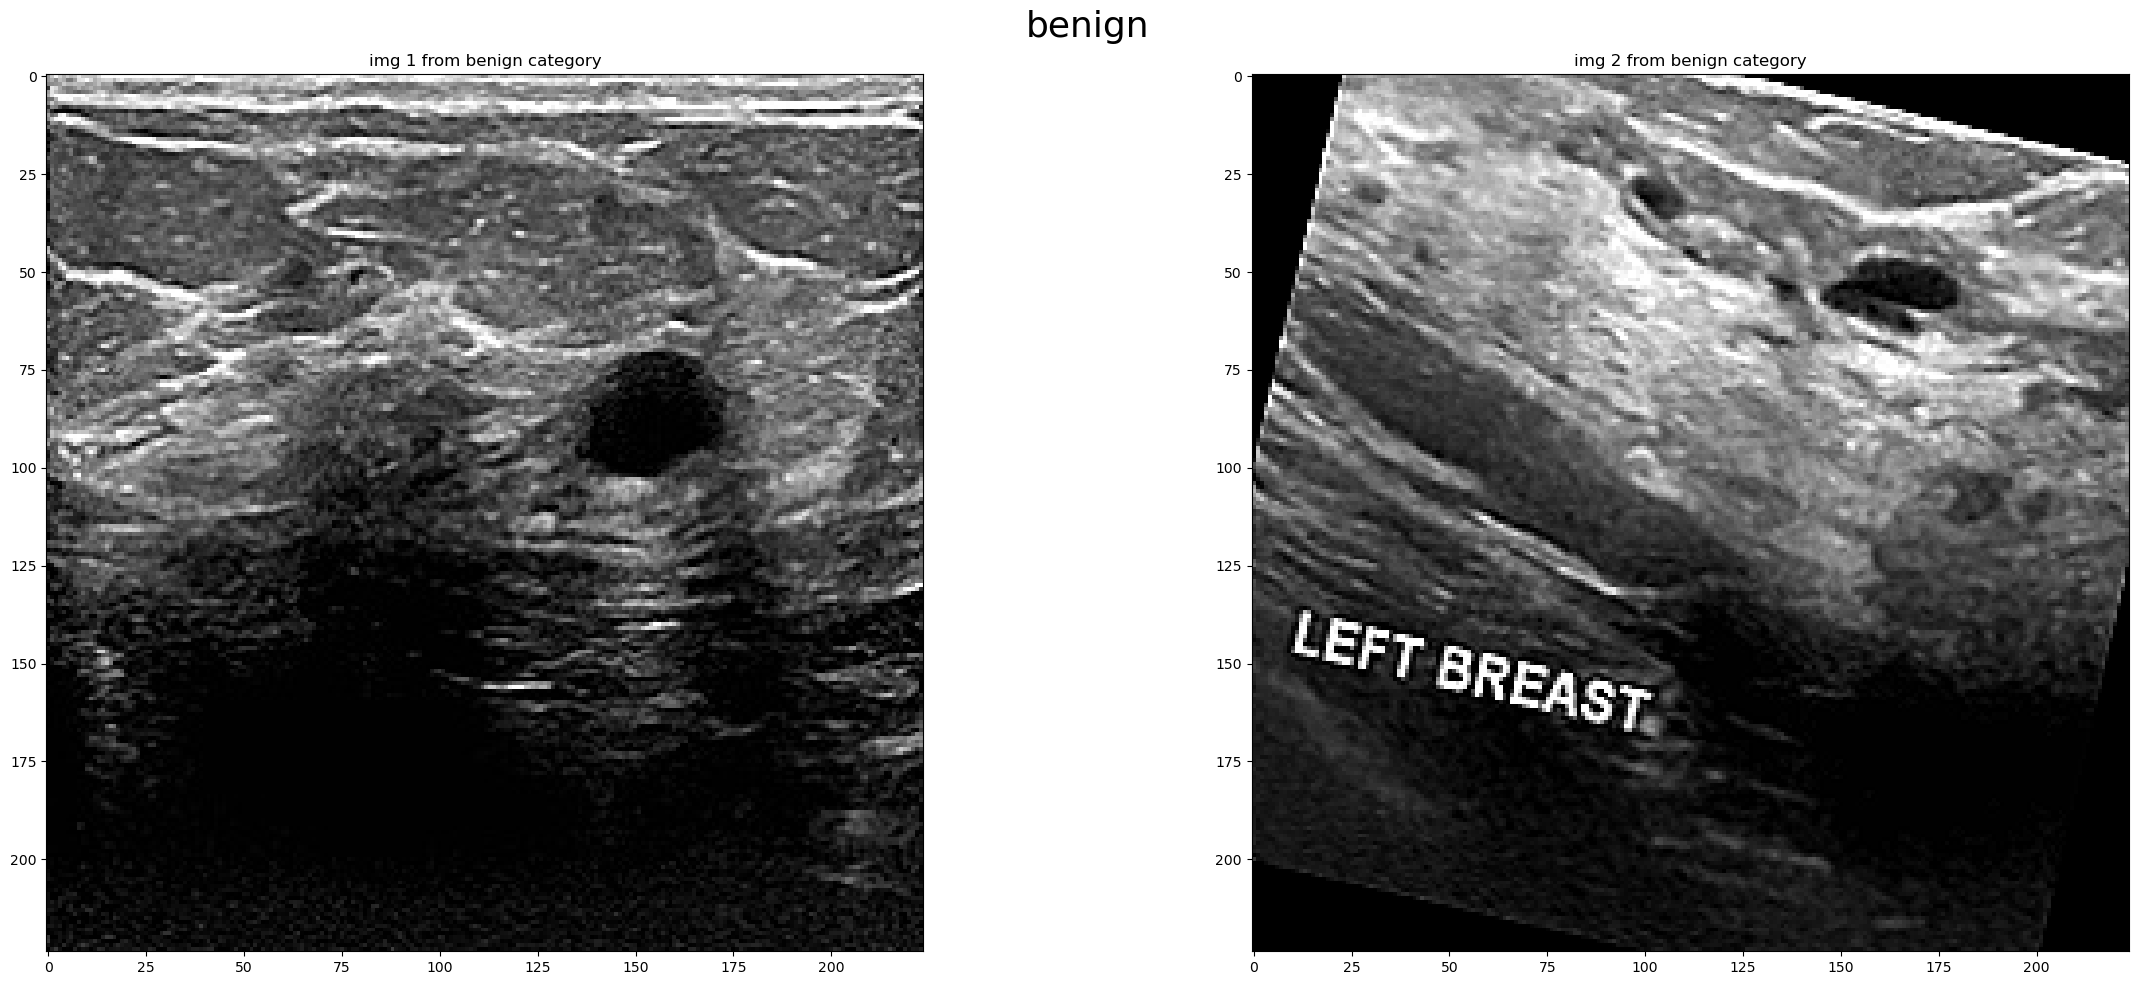

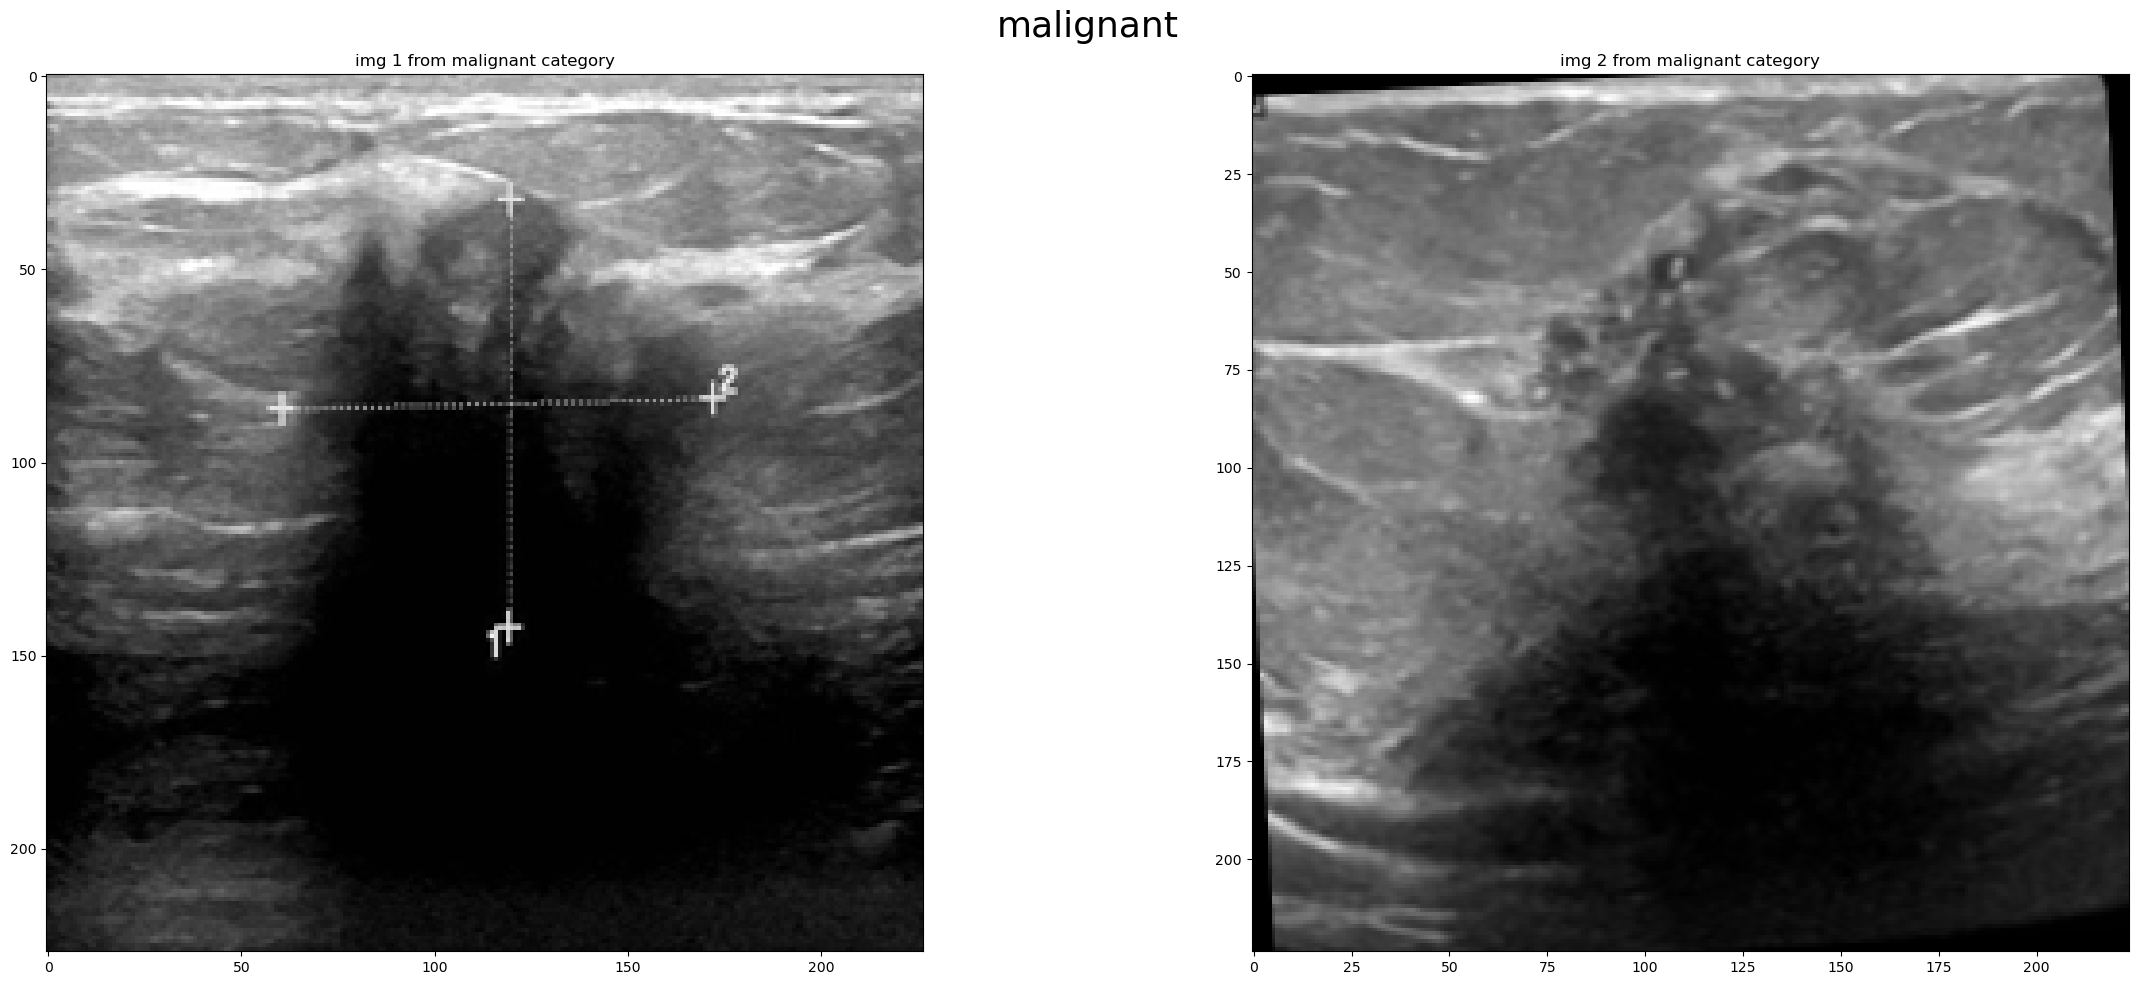

In [2]:
#Dados sobre conjunto de imagens de ultrassom de mama que contém 2 Classes [benigno, maligno] Exibindo 2 imagens de cada classe

import os
import cv2
import matplotlib.pyplot as plt

# Novo caminho da base de dados
folder_name = '/home/pc/Projeto/Ultrasound Breast Images for Breast Cancer/ultrasound_dataset/train'
files_names = ['benign', 'malignant']  # Apenas as duas classes desejadas

for file in files_names:
    path = os.path.join(folder_name, file)
    x = 0
    fig, axes = plt.subplots(1, 2, figsize=(25, 10))  
    
    for img in os.listdir(path):
        if not img.lower().endswith(('.png', '.jpg', '.jpeg')):
            continue  # Ignora arquivos que não são imagens

        img_path = os.path.join(path, img)
        if not os.path.isfile(img_path):
            continue  # Garante que é um arquivo

        img_array = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
        if img_array is None:
            continue  # Ignora arquivos corrompidos ou inválidos

        axes[x].imshow(img_array, cmap='gray')
        axes[x].set_title(f"img {x+1} from {file} category")
        x += 1
        if x == 2: 
            break

    plt.suptitle(file, fontsize=26)
    plt.tight_layout()
    plt.show()

In [3]:
# Carregando dados

import os
import cv2
from tqdm import tqdm

# Caminho para a pasta contendo as imagens de treino
folder_name = '/home/pc/Projeto/Ultrasound Breast Images for Breast Cancer/ultrasound_dataset/train'

# Classes que queremos carregar
files_names = ['benign', 'malignant']

# Tamanho das imagens
img_sz = 224

# Lista para armazenar os dados de treino
training_data = []

def create_training_data():
    for file in files_names:
        path = os.path.join(folder_name, file)
        class_num = files_names.index(file)  # 0 para benign, 1 para malignant
        print(file, class_num)

        for img in tqdm(os.listdir(path)):
            img_path = os.path.join(path, img)

            # Filtros para evitar imagens indesejadas
            if not img.lower().endswith('.png'):
                continue
            if not os.path.isfile(img_path):
                continue

            img_array = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
            if img_array is None:
                continue  # evita erro se a imagem estiver corrompida

            new_array = cv2.resize(img_array, (img_sz, img_sz))
            training_data.append([new_array, class_num])

# Executar a função
create_training_data()


benign 0


100%|█████████████████████████████████████| 4074/4074 [00:02<00:00, 1488.05it/s]


malignant 1


100%|█████████████████████████████████████| 4042/4042 [00:03<00:00, 1244.99it/s]


In [4]:
# Os dados têm imagens benignas e malignas. Embaralhando e exibindo as primeiras 20 classes

import random

# Embaralha os dados de treino
random.shuffle(training_data)

# Exibe as primeiras 30 amostras com suas classes
for i in range(30):
    print(f"Sample {i+1}:")
    print("Class number:", training_data[i][1], "\n")


Sample 1:
Class number: 0 

Sample 2:
Class number: 1 

Sample 3:
Class number: 0 

Sample 4:
Class number: 0 

Sample 5:
Class number: 0 

Sample 6:
Class number: 0 

Sample 7:
Class number: 1 

Sample 8:
Class number: 1 

Sample 9:
Class number: 1 

Sample 10:
Class number: 1 

Sample 11:
Class number: 0 

Sample 12:
Class number: 1 

Sample 13:
Class number: 1 

Sample 14:
Class number: 0 

Sample 15:
Class number: 0 

Sample 16:
Class number: 0 

Sample 17:
Class number: 0 

Sample 18:
Class number: 0 

Sample 19:
Class number: 0 

Sample 20:
Class number: 0 

Sample 21:
Class number: 0 

Sample 22:
Class number: 1 

Sample 23:
Class number: 0 

Sample 24:
Class number: 0 

Sample 25:
Class number: 1 

Sample 26:
Class number: 0 

Sample 27:
Class number: 1 

Sample 28:
Class number: 1 

Sample 29:
Class number: 0 

Sample 30:
Class number: 1 



In [5]:
import numpy as np

X = []
y = []

# Percorre as amostras de treinamento
for feature, label in training_data:
    X.append(feature)
    y.append(label)

# Converte as listas em arrays numpy
X = np.array(X)
y = np.array(y)

# Adiciona a dimensão para o canal (escala de cinza)
X = np.expand_dims(X, axis=-1)  # Adiciona a dimensão do canal de cor (1 para grayscale)

# Verificando a forma de X e y
print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")


X shape: (7352, 224, 224, 1)
y shape: (7352,)


In [6]:
from sklearn.model_selection import train_test_split

# Divisão dos dados em treino e teste (80% treino, 20% teste)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Verificar as formas dos conjuntos de dados
print(X_train.shape)
print(y_train.shape)
print(X_test.shape)
print(y_test.shape)


(5881, 224, 224, 1)
(5881,)
(1471, 224, 224, 1)
(1471,)


In [7]:
# Valores únicos em y (Classes)

print(np.unique(y_train))

print(np.unique(y_test))

[0 1]
[0 1]


In [8]:
# Normalização para 0-1
X_train = X_train/255
X_test = X_test/255

In [9]:
import tensorflow as tf
from tensorflow.keras import layers, models

import tensorflow as tf
from tensorflow.keras import layers, models

def eca_block(input_feature, k_size=3):
    channel = input_feature.shape[-1]

    # Global Average Pooling
    x = layers.GlobalAveragePooling2D()(input_feature)  # (B, C)

    # Expand dims para Conv1D
    x = layers.Reshape((channel, 1))(x)  # (B, C, 1)

    # 1D Convolution (atenção local entre canais)
    x = layers.Conv1D(
        filters=1,
        kernel_size=k_size,
        padding='same',
        use_bias=False,
        kernel_initializer='he_normal'
    )(x)

    x = layers.Activation('sigmoid')(x)

    # Voltar para (1,1,C)
    x = layers.Reshape((1, 1, channel))(x)

    # Aplicar atenção
    return layers.Multiply()([input_feature, x])
    return feature

# Agora o modelo com ECA-Net
img_sz = 224

inputs = layers.Input(shape=(img_sz, img_sz, 1))

x = layers.Conv2D(32, (3, 3), padding='same', activation='relu')(inputs)
x = eca_block(x)
x = layers.BatchNormalization()(x)
x = layers.MaxPooling2D((2, 2))(x)

x = layers.Conv2D(64, (3, 3), padding='same', activation='relu')(x)
x = eca_block(x)
x = layers.BatchNormalization()(x)
x = layers.MaxPooling2D((2, 2))(x)

x = layers.Conv2D(128, (3, 3), dilation_rate=2, padding='same', activation='relu')(x)
x = eca_block(x)
x = layers.BatchNormalization()(x)
x = layers.MaxPooling2D((2, 2))(x)

x = layers.Conv2D(256, (3, 3), dilation_rate=2, padding='same', activation='relu')(x)
x = eca_block(x)
x = layers.BatchNormalization()(x)
x = layers.MaxPooling2D((2, 2))(x)

x = layers.GlobalAveragePooling2D()(x)

x = layers.Dense(128, activation='relu')(x)
x = layers.Dropout(0.4)(x)

x = layers.Dense(64, activation='relu')(x)

outputs = layers.Dense(2, activation='softmax')(x)

model = models.Model(inputs=inputs, outputs=outputs)

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

I0000 00:00:1775880402.383120   14639 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 9884 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 3080 Ti, pci bus id: 0000:08:00.0, compute capability: 8.6


In [10]:
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 224, 224,  │        320 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 32)        │          0 │ conv2d[0][0]      │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape (Reshape)   │ (None, 32, 1)     │          0 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d (Conv1D)     │ (None, 32, 1)     │          3 │ reshape[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 32, 1)     │          0 │ conv1d[0][0]      │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape_1 (Reshape) │ (None, 1, 1, 32)  │          0 │ activation[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multiply (Multiply) │ (None, 224, 224,  │          0 │ conv2d[0][0],     │
│                     │ 32)               │            │ reshape_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 224, 224,  │        128 │ multiply[0][0]    │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 112, 112,  │          0 │ batch_normalizat… │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 112, 112,  │     18,496 │ max_pooling2d[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 64)        │          0 │ conv2d_1[0][0]    │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape_2 (Reshape) │ (None, 64, 1)     │          0 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_1 (Conv1D)   │ (None, 64, 1)     │          3 │ reshape_2[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_1        │ (None, 64, 1)     │          0 │ conv1d_1[0][0]    │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape_3 (Reshape) │ (None, 1, 1, 64)  │          0 │ activation_1[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multiply_1          │ (None, 112, 112,  │          0 │ conv2d_1[0][0],   │
│ (Multiply)          │ 64)               │            │ reshape_3[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 112, 112,  │        256 │ multiply_1[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_1     │ (None, 56, 56,    │          0 │ batch_normalizat

 Total params: 431,054 (1.64 MB)

 Trainable params: 430,094 (1.64 MB)

 Non-trainable params: 960 (3.75 KB)

In [11]:
from tensorflow.keras.callbacks import EarlyStopping

early_stopping = EarlyStopping(monitor='val_loss',  # ou 'val_accuracy'
                               patience=10,          # número de épocas sem melhora antes de parar
                               restore_best_weights=True)  # restaura os melhores pesos

history = model.fit(X_train, y_train,
                    epochs=50,
                    validation_split=0.2,
                    batch_size=8,
                    callbacks=[early_stopping])

2026-04-11 01:06:55.603643: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:84] Allocation of 944111616 exceeds 10% of free system memory.
2026-04-11 01:06:56.438143: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:84] Allocation of 944111616 exceeds 10% of free system memory.


Epoch 1/50


2026-04-11 01:06:58.612149: I external/local_xla/xla/service/service.cc:163] XLA service 0x7ed0a0017b90 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2026-04-11 01:06:58.612161: I external/local_xla/xla/service/service.cc:171]   StreamExecutor device (0): NVIDIA GeForce RTX 3080 Ti, Compute Capability 8.6
2026-04-11 01:06:58.667456: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2026-04-11 01:06:59.015363: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:473] Loaded cuDNN version 92000
I0000 00:00:1775880426.203350   14781 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


588/588 ━━━━━━━━━━━━━━━━━━━━ 18s 14ms/step - accuracy: 0.6495 - loss: 0.6465 - val_accuracy: 0.5786 - val_loss: 1.3555
Epoch 2/50
588/588 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.7364 - loss: 0.5231 - val_accuracy: 0.7901 - val_loss: 0.4572
Epoch 3/50
588/588 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.7814 - loss: 0.4642 - val_accuracy: 0.7986 - val_loss: 0.4223
Epoch 4/50
588/588 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - accuracy: 0.8129 - loss: 0.4135 - val_accuracy: 0.7213 - val_loss: 0.5947
Epoch 5/50
588/588 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - accuracy: 0.8289 - loss: 0.3646 - val_accuracy: 0.5777 - val_loss: 1.1740
Epoch 6/50
588/588 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - accuracy: 0.8564 - loss: 0.3311 - val_accuracy: 0.7060 - val_loss: 0.6532
Epoch 7/50
588/588 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - accuracy: 0.8796 - loss: 0.2841 - val_accuracy: 0.7298 - val_loss: 0.5891
Epoch 8/50
588/588 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - accuracy: 0.8993 - loss: 0.2425 - val_accuracy: 0.8377 - va

In [12]:
loss, accuracy = model.evaluate(X_test, y_test)
print(f"Accuarcy of the model is : {accuracy*100:.2f} %")

2026-04-11 01:10:45.671671: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2026-04-11 01:10:45.671688: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2026-04-11 01:10:46.196569: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_466', 8 bytes spill stores, 8 bytes spill loads

2026-04-11 01:10:46.228402: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Re

40/46 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9811 - loss: 0.0646

2026-04-11 01:10:49.131108: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2026-04-11 01:10:49.131129: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2026-04-11 01:10:49.661328: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_466', 8 bytes spill stores, 8 bytes spill loads

2026-04-11 01:10:49.963557: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Re

46/46 ━━━━━━━━━━━━━━━━━━━━ 7s 80ms/step - accuracy: 0.9812 - loss: 0.0656
Accuarcy of the model is : 98.03 %


In [13]:
from sklearn.metrics import confusion_matrix
import numpy as np

# Fazer a predição com o modelo
y_pred = model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)

# Gerar a matriz de confusão
conf_mat = confusion_matrix(y_test, y_pred_classes)



46/46 ━━━━━━━━━━━━━━━━━━━━ 3s 32ms/step


In [14]:
y_pred = [np.argmax(i) for i in y_pred]
print(y_pred)

[np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(0), np.int64(0), np.int64(0), np.int64(1), np.int64(1), np.int64(0), np.int64(0), np.int64(0), np.int64(1), np.int64(0), np.int64(0), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(0), np.int64(0), np.int64(0), np.int64(1), np.int64(0), np.int64(1), np.int64(1), np.int64(0), np.int64(1), np.int64(0), np.int64(1), np.int64(1), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(1), np.int64(0), np.int64(1), np.int64(1), np.int64(0), np.int64(1), np.int64(0), np.int64(0), np.int64(0), np.int64(1), np.int64(0), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(0), np.int64(1), np.int64(0), np.int64(1), np.int64(1), np.int64(0), np.int64(1), np.int64(0), np.int64(1), np.int64(1), np.int64(0), np.int64(1), np.int64(1), np.int64(0), np.int64(0), np.int64(0), np.int64(1), np.int64(1), np.int64(0), np.int64(0), np.int64(1), np.int64(1), np.int64(0), np.int64(1)

In [15]:
# Supondo que você tenha as classes "Benign" e "Malignant"
comparison_df = pd.DataFrame({ 'Actual': y_test,'Predicted': y_pred})

print(comparison_df[:20])

    Actual  Predicted
0        1          1
1        1          1
2        1          1
3        1          1
4        1          1
5        0          0
6        0          0
7        0          0
8        1          1
9        1          1
10       0          0
11       0          0
12       0          0
13       1          1
14       0          0
15       0          0
16       1          1
17       1          1
18       0          1
19       1          1


In [16]:
from sklearn.metrics import classification_report
import numpy as np

# Obter as predições do modelo no conjunto de teste completo
y_pred_probs = model.predict(X_test)
y_pred = np.argmax(y_pred_probs, axis=1)

# Relatório de classificação
print(classification_report(y_test, y_pred, target_names=['benign', 'malignant']))


46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
              precision    recall  f1-score   support

      benign       0.98      0.98      0.98       649
   malignant       0.98      0.98      0.98       822

    accuracy                           0.98      1471
   macro avg       0.98      0.98      0.98      1471
weighted avg       0.98      0.98      0.98      1471



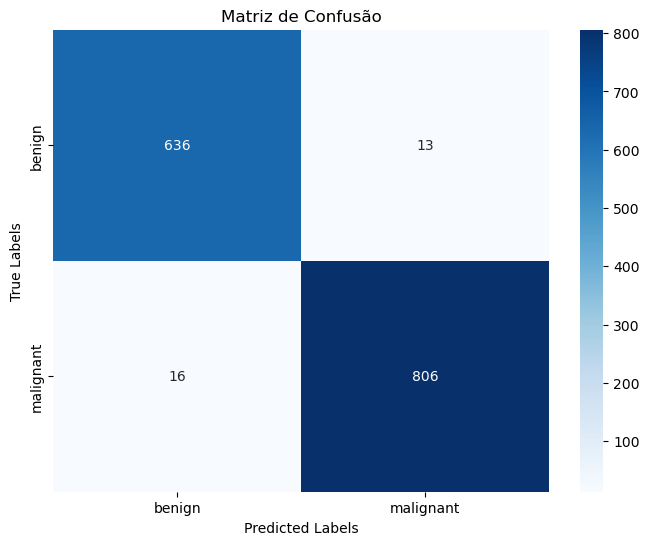

In [17]:
import seaborn as sns
import matplotlib.pyplot as plt

# Mostrar a matriz de confusão
plt.figure(figsize=(8, 6))
sns.heatmap(conf_mat, annot=True, fmt='d', cmap='Blues',
            xticklabels=['benign', 'malignant'],
            yticklabels=['benign', 'malignant'])
plt.ylabel('True Labels')
plt.xlabel('Predicted Labels')
plt.title('Matriz de Confusão')
plt.show()


1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step


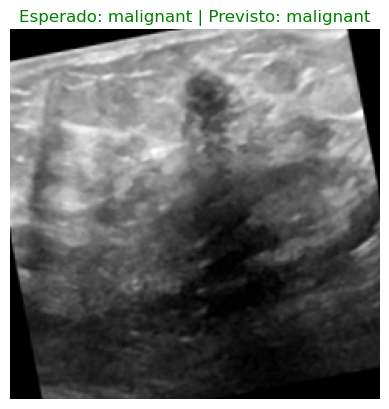

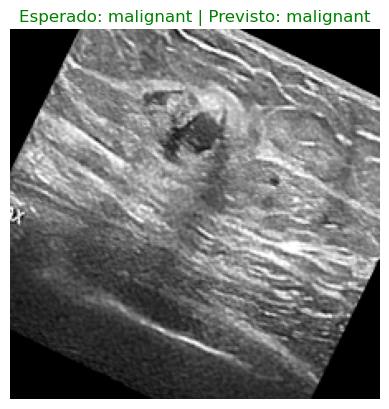

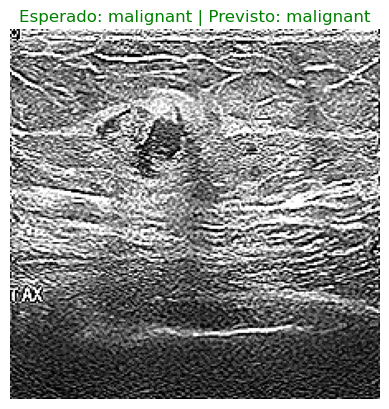

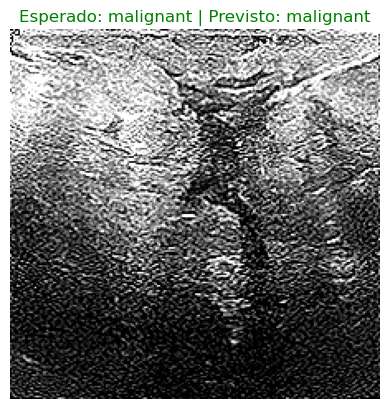

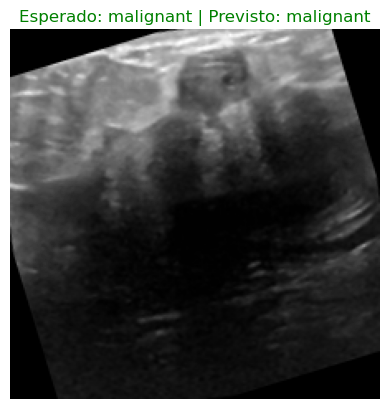

In [18]:
import matplotlib.pyplot as plt
import numpy as np

# Dicionário com as duas classes
class_names = {0: 'benign', 1: 'malignant'}

# Número de amostras que você quer prever
num_samples = 5

# Predição
predictions = model.predict(X_test[:num_samples])
predicted_classes = np.argmax(predictions, axis=1)

# Mostrar as imagens com a classe real e a prevista
for i in range(num_samples):
    plt.imshow(X_test[i].squeeze(), cmap='gray')  # .squeeze() remove canal extra se tiver
    esperado = class_names[y_test[i]]
    previsto = class_names[predicted_classes[i]]
    cor_titulo = 'green' if esperado == previsto else 'red'
    
    plt.title(f"Esperado: {esperado} | Previsto: {previsto}", color=cor_titulo)
    plt.axis('off')
    plt.show()


In [19]:
import os
import cv2
import numpy as np

# Caminhos das pastas
benign_path = '/home/pc/Projeto/Ultrasound Breast Images for Breast Cancer/ultrasound_dataset/val/benign'
malignant_path = '/home/pc/Projeto/Ultrasound Breast Images for Breast Cancer/ultrasound_dataset/val/malignant'

# Parâmetros
img_sz = 224
class_names = {0: 'benign', 1: 'malignant'}

def load_images_from_folder(folder_path, label):
    images = []
    labels = []

    for file in os.listdir(folder_path):
        img_path = os.path.join(folder_path, file)
        img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)

        if img is not None:
            img = cv2.resize(img, (img_sz, img_sz))
            img = img.astype('float32') / 255.0
            img = np.expand_dims(img, axis=-1)  # (224, 224, 1)

            images.append(img)
            labels.append(label)

    return images, labels


In [20]:
benign_imgs, benign_labels = load_images_from_folder(benign_path, 0)
malignant_imgs, malignant_labels = load_images_from_folder(malignant_path, 1)

X_val = np.array(benign_imgs + malignant_imgs)
y_val = np.array(benign_labels + malignant_labels)

print(f'Total de imagens: {X_val.shape[0]}')
print(f'Benign: {np.sum(y_val == 0)} | Malignant: {np.sum(y_val == 1)}')


Total de imagens: 900
Benign: 500 | Malignant: 400


In [21]:
loss, accuracy = model.evaluate(X_val, y_val, verbose=0)
print(f"Accuracy on test set: {accuracy*100:.2f}%")

Accuracy on test set: 92.22%


In [22]:
from sklearn.metrics import confusion_matrix

# Predição
y_pred_probs = model.predict(X_val)
y_pred_classes = np.argmax(y_pred_probs, axis=1)

# Matriz de confusão
conf_mat = confusion_matrix(y_val, y_pred_classes)

29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step


In [23]:
from sklearn.metrics import classification_report
import numpy as np

# 🔹 Predições no conjunto correto (900 imagens)
y_pred_probs = model.predict(X_val)
y_pred_classes = np.argmax(y_pred_probs, axis=1)

# 🔹 Checagem de consistência (ESSENCIAL)
print(len(y_val), len(y_pred_classes))  # Deve ser: 900 900

# 🔹 Relatório de classificação
print(classification_report(
    y_val,
    y_pred_classes,
    target_names=['benign', 'malignant']
))

29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
900 900
              precision    recall  f1-score   support

      benign       0.96      0.90      0.93       500
   malignant       0.89      0.95      0.92       400

    accuracy                           0.92       900
   macro avg       0.92      0.92      0.92       900
weighted avg       0.92      0.92      0.92       900



29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
900 900


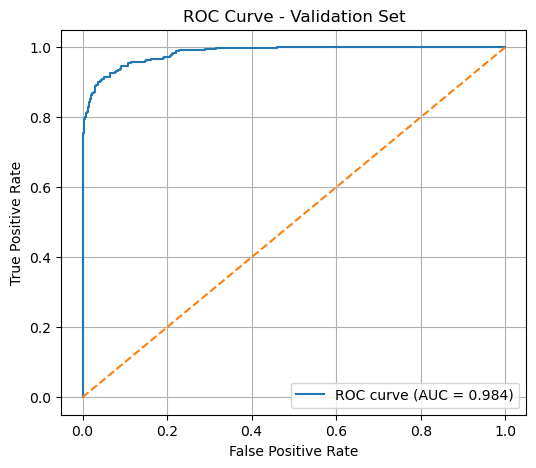

In [24]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# 🔹 1. Recalcular predições com o conjunto correto (900 imagens)
y_pred_probs = model.predict(X_val)

# 🔹 2. Pegar probabilidade da classe positiva (malignant = 1)
y_scores = y_pred_probs[:, 1]

# 🔹 3. Conferência (boa prática)
print(len(y_val), len(y_scores))  # Deve ser: 900 900

# 🔹 4. Curva ROC
fpr, tpr, _ = roc_curve(y_val, y_scores)
roc_auc = auc(fpr, tpr)

# 🔹 5. Plot
plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f'ROC curve (AUC = {roc_auc:.3f})')
plt.plot([0, 1], [0, 1], linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Validation Set')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

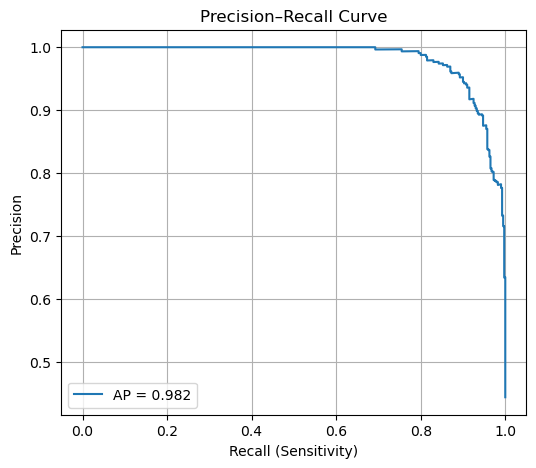

In [25]:
from sklearn.metrics import precision_recall_curve, average_precision_score

precision, recall, _ = precision_recall_curve(y_val, y_scores)
ap_score = average_precision_score(y_val, y_scores)

plt.figure(figsize=(6, 5))
plt.plot(recall, precision, label=f'AP = {ap_score:.3f}')
plt.xlabel('Recall (Sensitivity)')
plt.ylabel('Precision')
plt.title('Precision–Recall Curve')
plt.legend()
plt.grid(True)
plt.show()


In [26]:
print(len(y_val), len(y_pred_classes))

900 900


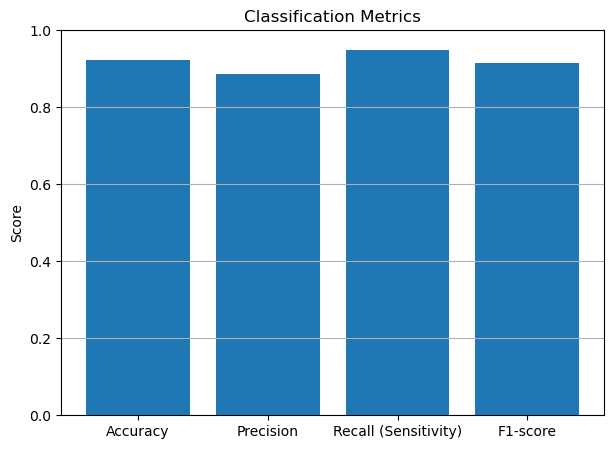

In [27]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

accuracy = accuracy_score(y_val, y_pred_classes)
precision = precision_score(y_val, y_pred_classes)
recall = recall_score(y_val, y_pred_classes)   # Sensibilidade (malignant)
f1 = f1_score(y_val, y_pred_classes)

metrics = {
    'Accuracy': accuracy,
    'Precision': precision,
    'Recall (Sensitivity)': recall,
    'F1-score': f1
}

plt.figure(figsize=(7, 5))
plt.bar(metrics.keys(), metrics.values())
plt.ylim(0, 1)
plt.ylabel('Score')
plt.title('Classification Metrics')
plt.grid(axis='y')
plt.show()


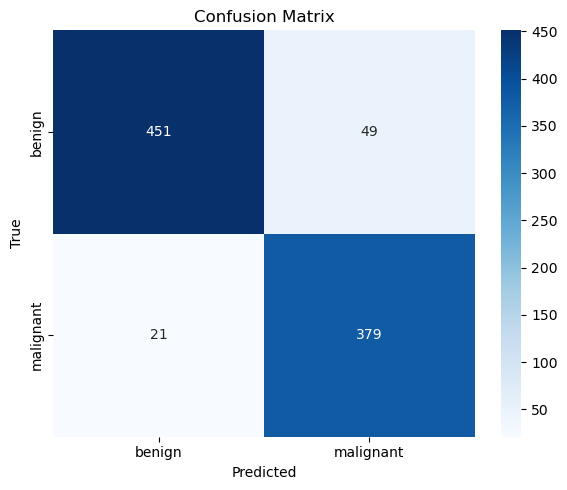

In [28]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(y_val, y_pred_classes)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['benign', 'malignant'],
    yticklabels=['benign', 'malignant']
)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.tight_layout()
plt.show()


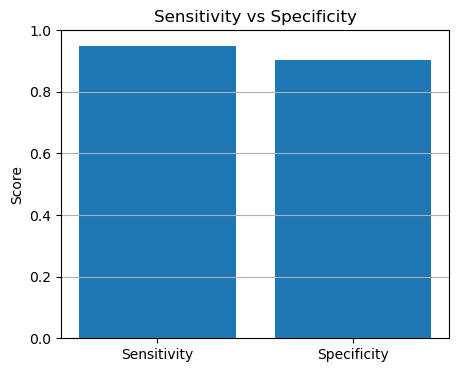

In [29]:
tn, fp, fn, tp = cm.ravel()

sensitivity = tp / (tp + fn)
specificity = tn / (tn + fp)

plt.figure(figsize=(5, 4))
plt.bar(['Sensitivity', 'Specificity'], [sensitivity, specificity])
plt.ylim(0, 1)
plt.ylabel('Score')
plt.title('Sensitivity vs Specificity')
plt.grid(axis='y')
plt.show()


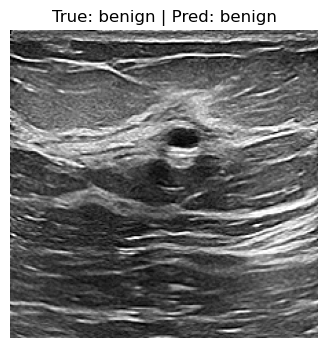

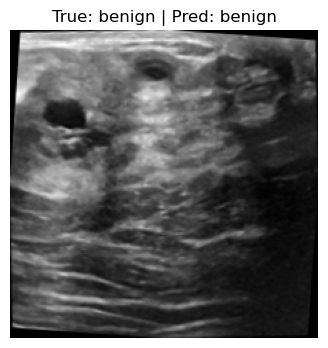

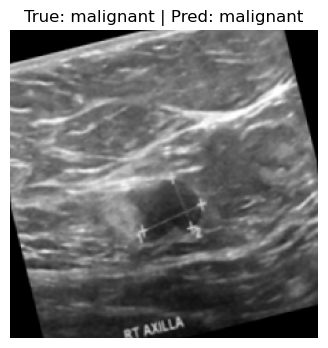

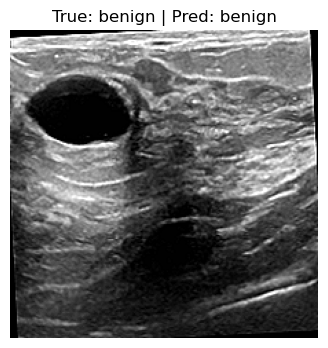

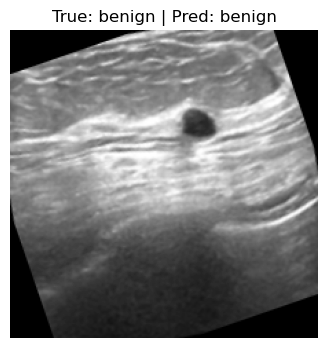

In [30]:
import numpy as np
import matplotlib.pyplot as plt

# Número de imagens para visualização
num_images = 5

# (Opcional) Para reprodutibilidade
np.random.seed(42)

for _ in range(num_images):
    # Índice aleatório
    random_idx = np.random.randint(0, len(X_val))

    # Imagem
    img = X_val[random_idx].squeeze()

    # Rótulos
    true_label = class_names[y_val[random_idx]]
    pred_label = class_names[y_pred_classes[random_idx]]

    # Plot
    plt.figure(figsize=(4, 4))
    plt.imshow(img, cmap='gray')
    plt.title(f"True: {true_label} | Pred: {pred_label}")
    plt.axis('off')
    plt.show()
